In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

In [2]:
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from keras.applications.vgg16 import preprocess_input

In [3]:
data = []
labels = []
classes = 43 
cur_path = os.getcwd() 
for i in range(classes): 
    path = os. path.join(cur_path,'train', str(i)) 
    images = os.listdir(path) 
    for a in images: 
        try: 
            image = Image.open(path + '/' + a) 
            image = image.resize((224,224)) 
            image = np.array(image) 
            data.append(image) 
            labels.append(i) 
        except: 
            print("Error loading image") 
data = np.array(data)
labels = np.array(labels)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(31367, 224, 224, 3) (7842, 224, 224, 3) (31367,) (7842,)


In [5]:
import keras
import keras.utils
from keras import utils as np_utils

In [6]:
base_model=keras.applications.vgg16.VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3))

In [7]:
#freeze the base model
base_model.trainable = False

In [8]:
#Create new model on top
from keras.models import Sequential
from keras.layers import Dense,Flatten,Dropout
model=Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(2048,activation='relu',kernel_initializer='he_normal'))
model.add(Dropout(0.35))
model.add(Dense(2048,activation='relu',kernel_initializer='he_normal'))
model.add(Dropout(0.35))
model.add(Dense(200,activation='softmax',kernel_initializer='glorot_normal'))

In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 2048)              51382272  
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense_1 (Dense)             (None, 2048)              4196352   
                                                                 
 dropout_1 (Dropout)         (None, 2048)              0         
                                                                 
 dense_2 (Dense)             (None, 200)               4

In [10]:
#Train the model on new data.
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [11]:
history=model.fit(X_train,y_train,epochs=10,validation_data=(X_test, y_test),workers=10,use_multiprocessing=True)

Epoch 1/10
981/981 [==============================] - 10324s 11s/step - loss: 2.0286 - accuracy: 0.7563 - val_loss: 0.2093 - val_accuracy: 0.9489
Epoch 2/10
981/981 [==============================] - 10372s 11s/step - loss: 0.4856 - accuracy: 0.9155 - val_loss: 0.1360 - val_accuracy: 0.9688
Epoch 3/10
981/981 [==============================] - 11026s 11s/step - loss: 0.3232 - accuracy: 0.9471 - val_loss: 0.1308 - val_accuracy: 0.9746
Epoch 4/10
981/981 [==============================] - 10360s 11s/step - loss: 0.3211 - accuracy: 0.9547 - val_loss: 0.1049 - val_accuracy: 0.9795
Epoch 5/10
981/981 [==============================] - 10226s 10s/step - loss: 0.2173 - accuracy: 0.9685 - val_loss: 0.2416 - val_accuracy: 0.9691
Epoch 6/10
981/981 [==============================] - 10194s 10s/step - loss: 0.2352 - accuracy: 0.9714 - val_loss: 0.1384 - val_accuracy: 0.9790
Epoch 7/10
981/981 [==============================] - 10441s 11s/step - loss: 0.1831 - accuracy: 0.9759 - val_loss: 0.1289 -

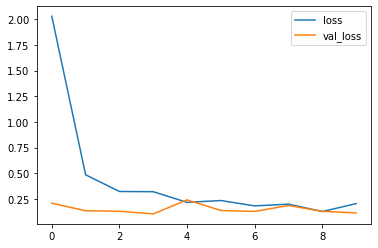

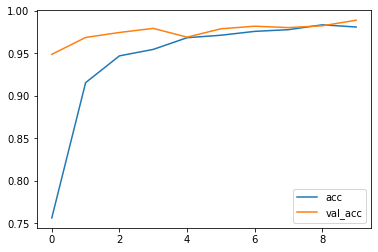

In [12]:
#Some visualizations
#Loss
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()
plt.show()
#Accuracy
plt.plot(history.history['accuracy'],label='acc')
plt.plot(history.history['val_accuracy'],label='val_acc')
plt.legend()
plt.show()

In [13]:
model.save('traffic_classifier_vgg16.h5')

In [15]:
from sklearn.metrics import accuracy_score
y_test = pd.read_csv('Test.csv')
labels = y_test["ClassId"].values
imgs = y_test["Path"].values
data=[]
for img in imgs:
   image = Image.open(img)
   image = image.resize((224,224))
   data.append(np.array(image))
X_test=np.array(data)
predict_x=model.predict(X_test) 
classes_x=np.argmax(predict_x,axis=1)

KeyboardInterrupt: 

In [16]:
from sklearn.metrics import accuracy_score
print(accuracy_score(labels, classes_x))

0.8969121140142517
